In [1]:
!pip install ultralytics roboflow -q
!pip install python-dotenv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 96.0 MB/s eta 0:00:00


In [5]:
from dotenv import load_dotenv
from pathlib import Path
from roboflow import Roboflow
import os

env_path = Path(__file__).resolve().parent.parent / ".env"

load_dotenv(env_path)

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")

if not ROBOFLOW_API_KEY:
    raise ValueError("ROBOFLOW_API_KEY not found in .env")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

car_project = rf.workspace("test").project("test")

car_dataset = car_project.version(1).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Self-Driving-Car-1 in yolov8:: 100%|██████████| 26563/26563 [00:04<00:00, 6222.93it/s]


In [6]:
import os

print(os.listdir("/content/Self-Driving-Car-1"))

['export', 'data.yaml', 'README.roboflow.txt', 'README.dataset.txt']


In [7]:
import os
import random
import shutil

base_path = car_dataset.location + "/export"  # adjust if needed

images_path = os.path.join(base_path, "images")
labels_path = os.path.join(base_path, "labels")

output_path = car_dataset.location + "/split"

splits = ["train", "valid", "test"]

for split in splits:
    os.makedirs(os.path.join(output_path, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(output_path, split, "labels"), exist_ok=True)

# get all images
images = [f for f in os.listdir(images_path) if f.endswith(".jpg")]

random.shuffle(images)

train_split = int(0.8 * len(images))
val_split = int(0.9 * len(images))

train_files = images[:train_split]
val_files = images[train_split:val_split]
test_files = images[val_split:]

def move_files(files, split):
    for file in files:
        shutil.copy(os.path.join(images_path, file),
                    os.path.join(output_path, split, "images", file))

        label_file = file.replace(".jpg", ".txt")
        if os.path.exists(os.path.join(labels_path, label_file)):
            shutil.copy(os.path.join(labels_path, label_file),
                        os.path.join(output_path, split, "labels", label_file))

move_files(train_files, "train")
move_files(val_files, "valid")
move_files(test_files, "test")

print("Done splitting dataset ✅")

Done splitting dataset ✅


In [8]:
data_yaml = """
path: /content/Self-Driving-Car-1/split
train: train/images
val: valid/images
test: test/images

nc: 11
names: ["biker", "car", "pedestrian", "trafficLight", "trafficLight-Green", "trafficLight-GreenLeft",
 "trafficLight-Red", "trafficLight-RedLeft", "trafficLight-Yellow", "trafficLight-YellowLeft", "truck"]
"""

with open("data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml created ✅")

data.yaml created ✅


In [9]:
!cat data.yaml


path: /content/Self-Driving-Car-1/split
train: train/images
val: valid/images
test: test/images

nc: 11
names: ["biker", "car", "pedestrian", "trafficLight", "trafficLight-Green", "trafficLight-GreenLeft",
 "trafficLight-Red", "trafficLight-RedLeft", "trafficLight-Yellow", "trafficLight-YellowLeft", "truck"]


In [ ]:
!cat Self-Driving-Car-1/data.yaml

names:
- biker
- car
- pedestrian
- trafficLight
- trafficLight-Green
- trafficLight-GreenLeft
- trafficLight-Red
- trafficLight-RedLeft
- trafficLight-Yellow
- trafficLight-YellowLeft
- truck
nc: 11
roboflow:
  license: MIT
  project: self-driving-car-0mkga
  url: https://universe.roboflow.com/datasciencepro/self-driving-car-0mkga/dataset/1
  version: 1
  workspace: datasciencepro
test: ../test/images
train: ../train/images
val: ../valid/images


In [ ]:
import os

base_path = "/content/Self-Driving-Car-1/split"

def count_images(folder):
    return len([f for f in os.listdir(folder) if f.endswith((".jpg", ".png", ".jpeg"))])

train_count = count_images(os.path.join(base_path, "train/images"))
val_count = count_images(os.path.join(base_path, "valid/images"))
test_count = count_images(os.path.join(base_path, "test/images"))

total = train_count + val_count + test_count

print(f"Train: {train_count}")
print(f"Valid: {val_count}")
print(f"Test:  {test_count}")
print(f"Total: {total}")

print("\nPercentages:")
print(f"Train: {train_count/total:.2%}")
print(f"Valid: {val_count/total:.2%}")
print(f"Test:  {test_count/total:.2%}")

Train: 10624
Valid: 1328
Test:  1328
Total: 13280

Percentages:
Train: 80.00%
Valid: 10.00%
Test:  10.00%


In [2]:
from ultralytics import YOLO
model= YOLO("yolov8n.pt")

model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="car_model",

    fliplr=0.5,
    hsv_v=0.1,
    hsv_s=0.1,

    mosaic=1.0,
    mixup=0.0,

)

KeyboardInterrupt: 

In [ ]:
import os

base_path = "/content/runs/detect/car_model/weights"
print(os.listdir(base_path))

['last.pt', 'best.pt']


In [1]:
from ultralytics import YOLO

# model = YOLO("/content/runs/detect/car_model/weights/best.pt")
model = YOLO("/content/best (1).pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [11]:
metrics = model.val()
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)


Ultralytics 8.4.43 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1411.2±470.5 MB/s, size: 44.3 KB)
val: Scanning /content/Self-Driving-Car-1/split/valid/labels... 1328 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1328/1328 2.1Kit/s 0.6s
val: /content/Self-Driving-Car-1/split/valid/images/1478897760163798179_jpg.rf.ad18a9d7cc8f89b926569d36a8b692ce.jpg: 1 duplicate labels removed
val: New cache created: /content/Self-Driving-Car-1/split/valid/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 23% ━━╸───────── 19/83 4.9it/s 6.0s<13.1s


KeyboardInterrupt: 

In [ ]:
!ls runs/detect/
from google.colab import files

files.download("runs/detect/car_model/weights/best.pt")
# files.download('runs/classify/car_model/weights/best.pt')

car_model  val


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving image1.jpg to image1 (1).jpg


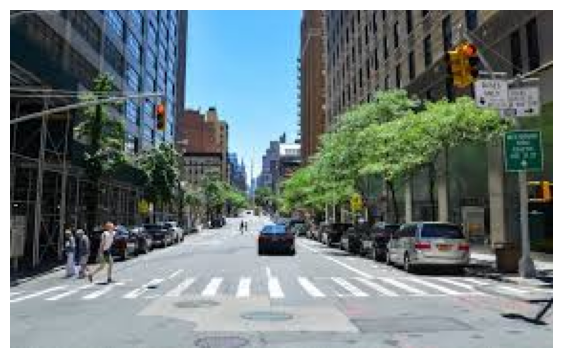


image 1/1 /content/image1 (1).jpg: 416x640 7 cars, 3 pedestrians, 82.1ms
Speed: 2.5ms preprocess, 82.1ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 640)


In [12]:
from google.colab import files
from PIL import Image
import io, os
import matplotlib.pyplot as plt
from ultralytics import YOLO

# car_upload = files.upload()
# car_filename = list(car_upload.keys())[0]
# car_model = YOLO(car_filename)
# print('Car model loaded')


uploaded = files.upload()
for filename in uploaded.keys():
    image_bytes = uploaded[filename]
    image_path = filename
    with open(image_path, 'wb') as f:
        f.write(image_bytes)


def show_image(image_path):
    img = Image.open(image_path)
    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

show_image(image_path)


# model = YOLO("/content/runs/detect/car_model/weights/best.pt")

results = model(image_path)

In [13]:
from collections import Counter

def detections_summary(results, conf_threshold=0.4):
    names = results.names
    boxes = results.boxes

    labels = []

    for box in boxes:
        conf = float(box.conf[0])
        if conf < conf_threshold:
            continue
        cls_id = int(box.cls[0])
        labels.append(names[cls_id])

    counts = Counter(labels)
    return "\n".join([f"{k}: {v}" for k, v in counts.items()])

In [14]:

from openai import OpenAI
import base64
import io
from PIL import Image

from dotenv import load_dotenv
from pathlib import Path
import os

env_path = Path(__file__).resolve().parent.parent / ".env"

load_dotenv(env_path)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

if not GROQ_API_KEY:
    raise ValueError("GROQ_API_KEY not found in .env")

client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1"
)

MODEL_NAME = "meta-llama/llama-4-scout-17b-16e-instruct"

print("Groq client ready")

def encode_image(image_path, max_size=128) -> str:
    img = Image.open(image_path)
    img.thumbnail((max_size, max_size))
    if img.mode != "RGB":
        img = img.convert("RGB")
    buffer = io.BytesIO()
    img.save(buffer, format="JPEG", quality=50)
    b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
    print(f"Image size: {len(b64) / 1024:.1f} KB, dimensions: {img.size}")
    return b64

def ask_llava_with_context(report):
    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": f"""
You are an intelligent driving scene analysis system.

You are given objects detected from a road image by a vision model.
These detections are accurate and should be trusted.

Detected Objects:
{report}

Based on this, provide:

1. **Scene Description**
   - Describe what is happening in the scene
   - Mention relationships between objects (e.g., car approaching red light, pedestrian crossing)

2. **Risk Assessment**
   - Identify potential dangers (collision risk, pedestrian proximity, traffic signals)
   - Classify risk level: low / medium / high

3. **Recommended Driving Action**
   - What should the driver or autonomous system do?
   - Be specific (e.g., slow down, stop, yield, proceed carefully)

4. **Reasoning**
   - Explain WHY you recommended that action based on detected objects

Keep it concise but intelligent. Focus on real-world driving logic.
"""
        }]
    )
    return response.choices[0].message.content


def ask_llava_with_image(image_path, report):
    b64_image = encode_image(image_path)

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[{
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{b64_image}"
                    }
                },
                {
                    "type": "text",
                    "text": f"""
You are an intelligent driving scene analysis system.

You are given objects detected from a road image by a vision model.
These detections are accurate and should be trusted.

Detected Objects:
{report}

Based on this, provide:

1. **Scene Description**
   - Describe what is happening in the scene
   - Mention relationships between objects (e.g., car approaching red light, pedestrian crossing)

2. **Risk Assessment**
   - Identify potential dangers (collision risk, pedestrian proximity, traffic signals)
   - Classify risk level: low / medium / high

3. **Recommended Driving Action**
   - What should the driver or autonomous system do?
   - Be specific (e.g., slow down, stop, yield, proceed carefully)

4. **Reasoning**
   - Explain WHY you recommended that action based on detected objects

Keep it concise but intelligent. Focus on real-world driving logic.
"""
                }
            ]
        }]
    )
    return response.choices[0].message.content

In [16]:
results = model(image_path)[0]

report = detections_summary(results)

print("=== YOLO DETECTIONS ===")
print(report)

# response = ask_llava_with_context(report)

# print("\n=== LLaVA ANALYSIS ===")
# print(response)

response2 = ask_llava_with_image(image_path, report)
print("\n=== LLaVA ANALYSIS WITH IMAGE ===")
print(response2)


image 1/1 /content/image1 (1).jpg: 416x640 7 cars, 3 pedestrians, 9.0ms
Speed: 3.5ms preprocess, 9.0ms inference, 1.4ms postprocess per image at shape (1, 3, 416, 640)
=== YOLO DETECTIONS ===
car: 4
pedestrian: 1
Image size: 3.4 KB, dimensions: (128, 80)


InternalServerError: Error code: 500 - {'error': {'message': 'model runner has unexpectedly stopped, this may be due to resource limitations or an internal error, check ollama server logs for details', 'type': 'api_error', 'param': None, 'code': None}}


image 1/1 /content/image1 (2).jpg: 416x640 7 cars, 3 pedestrians, 12.8ms
Speed: 4.4ms preprocess, 12.8ms inference, 3.3ms postprocess per image at shape (1, 3, 416, 640)


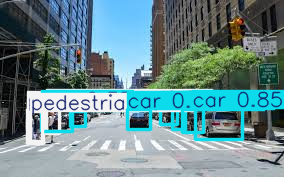

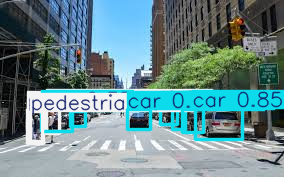

In [ ]:
results = model(image_path)[0]
report = detections_summary(results)
results.show()